<a href="https://colab.research.google.com/github/Makande340/A03-knn/blob/main/kNN_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

# Phase 1 Question 1 answers

Q1.1 - Regression consists of the prediction of numerical values whereas classification consists of the prediction of categorical values.

Q1.2 - Complex matrixes/tables are utilized to count the number of predictions between actual and predicted classes

Q1.3 - SSE essentially quantifies the overall difference between actual/observed and predicted value points

Q1.4 - Underfitting is when the model itself lacks the bandwith to be able to capture relationships within the datasets outcomes. Overfitting is when model fits datatset feature will not prominently or consistently show up.

Q1.5 - Splitting the data is mportant because it allows for the avoidance of overfitting, all observations existing and new are accounted for balanced bias and variance awareness with generatlization towards observations that were not used.


Q1.6 - Class labels provide concrete assessment with clear communcation of value, but weakness is that model confidence is not clear/states
     - Prediction labels strength provides opportunity for uncertainty to be measured, quantified, and calculated, but a weakness is

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
mine_type
1    0.210059
2    0.207101
3    0.195266
4    0.195266
5    0.192308
Name: proportion, dtype: float64


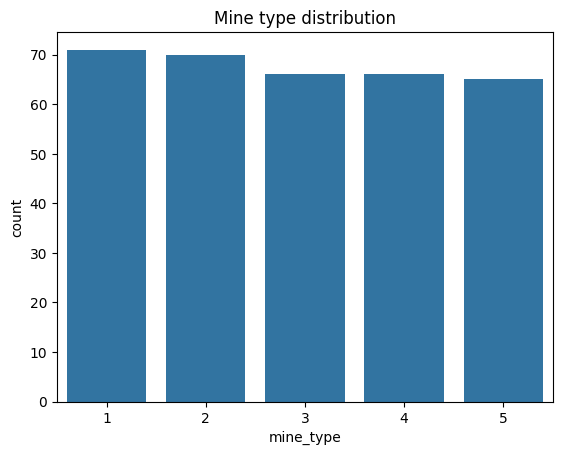

          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000
voltage    0
height     0
soil       0
dtype: int64
Duplicates: 0


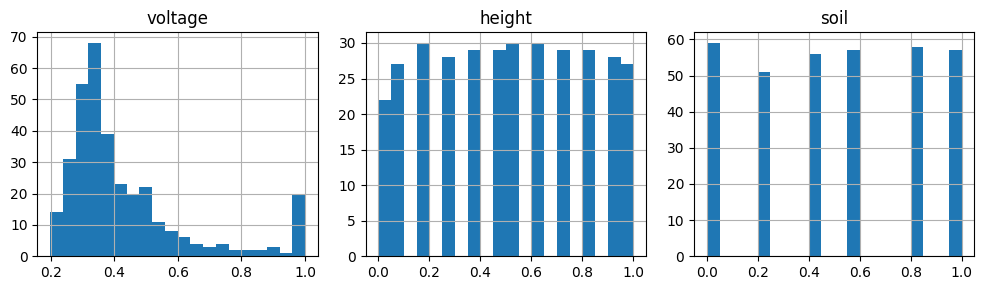

           train  valid
mine_type              
1             35     36
2             35     35
3             33     33
4             33     33
5             33     32
Best k: 2
Predicted   1   2   3   4  5
Actual                      
1          27   0   5   2  2
2           0  31   2   1  1
3          10   2  10  10  1
4          15   6   3   9  0
5          15   0  10   5  2
Accuracy: 0.46745562130177515
Actual
1    0.75
2    0.89
3    0.30
4    0.27
5    0.06
dtype: float64


In [15]:
#Q2.1:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

url = "./land_mines.csv"
df = pd.read_csv(url)
#data loading din din din din


target = "mine_type"
features = ["voltage", "height", "soil"]

print(df[target].value_counts().sort_index())
print(df[target].value_counts(normalize=True).sort_index())
sns.countplot(x=target, data=df)
plt.title("Mine type distribution")
plt.show()

print(df[features].describe())
print(df[features].isna().sum())
print("Duplicates:", df.duplicated().sum())

df[features].hist(bins=20, figsize=(10, 3), layout=(1, 3))
plt.tight_layout()
plt.show()

#target label can be seen as the mine type with it consisting of five catergorical classes that are balanced.
#feature include voltage (numeric), height (numeric), and soil (discrete levels).


#Q2.2


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.50, stratify=eval_y, random_state=65
)

eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)


print(pd.DataFrame({
    "train": eval_y_train.value_counts().sort_index(),
    "valid": eval_y_valid.value_counts().sort_index(),
}))
#splits into even training sets and validation sets using three key features of voltage, height, and soil

#Q2.3

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

k_values = range(1, 31)
cv_scores = []
valid_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # k selected using cross-validation on the traning set
    cv_scores.append(cross_val_score(knn, eval_X_train_scaled, eval_y_train, cv=5).mean())
    # validation accuracy used for comparison
    knn.fit(eval_X_train_scaled, eval_y_train)
    valid_scores.append(knn.score(eval_X_valid_scaled, eval_y_valid))

best_k = k_values[int(np.argmax(cv_scores))]
print("Best k:", best_k)

#trained kNN classifierss on scaled trainin data, estimating accuracy with cross-validation on solely the training set

#Q2.4

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(eval_X_train_scaled, eval_y_train)
pred = knn.predict(eval_X_valid_scaled)

# confusion table
cm = pd.crosstab(eval_y_valid, pred, rownames=["Actual"], colnames=["Predicted"])
print(cm)

# accuracy
print("Accuracy:", accuracy_score(eval_y_valid, pred))

print((pd.Series(cm.values.diagonal(), index=cm.index) / cm.sum(axis=1)).round(2))

#k-NN model showcases 47% accuracy on the test set, above 20 perecent from random guessing. type 2 and type 1 boast the best at 89% and 75% respectively, the worst on type 3 and type 4,near failing at type 5
#perfomance at their best when voltage seperates class and worse when class overlaps

#Q2.5 -
#I would advise one to use the model as a reference but not as the set say for the type of mine itself. Types should be utilized as ways to verify, checks before anything is acted upon. Be wary of what is classified as type 1 because some types can be mislabled, important to take into account the possibilities of overlap

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:**

- **AI tool and model used:** [Gemini]

### Q1 - Prompts used



```
# This is formatted as code
```

1. here is my phase 1 questions and answers, please revise accordingly

**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.


# Phase 1 Question 1 answers

Q1.1 - Regression consists of the prediction of numerical values whereas classification consists of the prediction of categorical values.

Q1.2 - Complex matrixes/tables are utilized to count the number of predictions between actual and predicted classes

Q1.3 - SSE essentially quantifies the overall difference between actual/observed and predicted value points

Q1.4 - Underfitting is when the model itself lacks the bandwith to be able to capture relationships within the datasets outcomes. Overfitting is when model fits datatset feature will not prominently or consistently show up.

Q1.5 - Splitting the data is mportant because it allows for the avoidance of overfitting, all observations existing and new are accounted for balanced bias and variance awareness with generatlization towards observations that were not used.


Q1.6 - Class labels provide concrete assessment with clear communcation of value, but weakness is that model confidence is not clear/states
     - Prediction labels strength provides opportunity for uncertainty to be measured, quantified, and calculated, but a weakness is




### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

Q1.1: Changed "numerical" and "categorical values" to continuous numerical values and discrete categorical labels.

Q1.2: Named the table a confusion matrix and added the four outcome types (True/False Positives and Negatives).

Q1.3: Added the mathematical definition of SSE (sum of squared residuals/deviations between actual $y_i$ and predicted $\hat{y}_i$).

Q1.4: Replaced informal wording ("lacks bandwidth", "fit feature") with standard terms: high bias (underfitting) and high variance/memorizing noise (overfitting).

Q1.5: Fixed typos ("mportant", "generatlization") and explicitly linked train/test splits to evaluating generalization and tuning the bias-variance tradeoff.

Q1.6: Completed your unfinished sentence on probability distributions, adding uncertainty quantification (strength) and the need for a decision threshold (weakness).

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
|| Change | Decision | Reason and verification |
| --- | --- | --- |
| **1. Refine Q1.1 definitions** | Accept | Added "continuous numerical" and "discrete categorical" to ensure precise machine learning terminology for regression vs. classification. |
| **2. Formalize Q1.2 confusion matrix details** | Accept | Replaced "complex matrixes" with "confusion matrix" and specified True/False Positives/Negatives to explain what performance aspects it measures. |
| **3. Clarify Q1.3 SSE calculation** | Accept | Replaced "overall difference" with the exact mathematical concept of "sum of squared residuals/deviations" between observed ($y_i$) and predicted ($\hat{y}_i$) values. |
| **4. Fix Q1.4 overfitting/underfitting language** | Accept | Replaced informal terms ("lacks bandwidth", "fit feature") with high bias underfitting and high variance/memorizing training noise overfitting. |
| **5. Correct Q1.5 typos and generalize logic** | Accept |typos ("mportant", "generatlization") and explicitly linked test-set evaluation of $k$ to measuring generalization and balancing bias vs. variance. |
| **6. Complete Q1.6 probability distributions answer** | Accept | Finished the incomplete sentence by identifying uncertainty quantification and threshold tuning as key strengths, and administrative threshold overhead as a weakness.


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

# Your Phase 2 solution to the problem goes here.

Q1.1: What is the difference between regression and classification?

    Answer: Regression is a supervised learning task used to predict continuous numerical values (e.g., house prices or temperature). Classification is used to predict discrete categorical class labels (e.g., spam vs. non-spam or disease diagnosis).

Q1.2: What is a confusion table? What does it help us understand about a model's performance?

    Answer: A confusion matrix (or table) is a layout that visualizes the performance of a classification algorithm. By comparing actual target values against predicted class labels, it displays the counts of True Positives, True Negatives, False Positives, and False Negatives. This helps us evaluate where a model makes mistakes beyond simple accuracy (e.g., identifying whether the model suffers more from false alarms or missed detections).

Q1.3: What does the SSE quantify about a particular model?

    Answer: The Sum of Squared Errors (SSE) quantifies the total residual variance or total squared deviation between the actual observed values (yi​) and the model's predicted values (y^​i​). It measures the total magnitude of error across all observations in a dataset; lower SSE values indicate a closer fit to the data.

Q1.4: What are overfitting and underfitting?

    Answer:

        Underfitting occurs when a model is too simple to capture the underlying patterns or relationships in the data (high bias). It performs poorly on both the training data and unseen test data.

        Overfitting occurs when a model is overly complex and memorizes noise or random fluctuations specific to the training set (high variance). It performs exceptionally well on training data but fails to generalize to new, unseen data.

Q1.5: Why does splitting the data into training and testing sets, and choosing k by evaluating accuracy or SSE on the test set, improve model performance?

    Answer: Splitting data into separate training and test sets ensures an unbiased evaluation of how well the model generalizes to unseen data. Evaluating metrics (such as accuracy or SSE) on the test set—or via cross-validation—prevents tuning hyperparameters (like k in k-Nearest Neighbors) to noise. This process helps strike an optimal balance between bias and variance, avoiding both underfitting and overfitting.

Q1.6: With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

    Answer:

        Class Labels:

            Strengths: Provides a direct, actionable decision or recommendation that is easy to communicate to stakeholders.

            Weaknesses: Conceals model uncertainty and confidence. It treats borderline predictions (e.g., 51% confidence) the same as highly confident predictions (e.g., 99% confidence).

        Probability Distributions:

            Strengths: Quantifies predictive uncertainty, allowing for risk assessment, threshold tuning (e.g., adjusting sensitivity vs. specificity), and cost-sensitive decision-making.

            Weaknesses: Requires establishing an external decision threshold to take concrete action, and can be harder to explain to non-technical end users.

### *Reflection on AI assistance
In your own words without generative AI.

AI compared to my response had a lot of visible similarities but mainly brushed up on the formalities and overall structure of my responses.A lot of my word play could have drew in more into the required terminology to help better explain my answers, AI fixed that. I could have also done better in the thoroughness of my answers into terms getting to the crux of my answers concisely, Gemini also fixed that. There were no difficulties in Gemini's responses other than it sometimes using a little bit more excessive wording explain answers, although correct but maybe not the most necessary or required. I've dabbled upon different AI models for different usages, and I am satisfied with Gemini's ability to construct linuistically correct answers, hence my decision to use Gemini for questions 1 of phase 2. Whhen it comes down to actually making code changes in relation to actionable data I am immediately working on, Claude is the move.

### Q2 - Prompts used:

Here are my phase 2 questions and answers, come up with a numbered list of changes i can make.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.
Load the data. Perform some EDA, summarizing the target label and the features.
Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
Build a $k$-NN classifier. Explain how you select $k$.
Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.
#Q2.1:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

url = "./land_mines.csv"
df = pd.read_csv(url)
data loading din din din din


target = "mine_type"
features = ["voltage", "height", "soil"]

print(df[target].value_counts().sort_index())
print(df[target].value_counts(normalize=True).sort_index())
sns.countplot(x=target, data=df)
plt.title("Mine type distribution")
plt.show()

print(df[features].describe())
print(df[features].isna().sum())
print("Duplicates:", df.duplicated().sum())

df[features].hist(bins=20, figsize=(10, 3), layout=(1, 3))
plt.tight_layout()
plt.show()

target label can be seen as the mine type with it consisting of five catergorical classes that are balanced.
#feature include voltage (numeric), height (numeric), and soil (discrete levels).


Q2.2


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.50, stratify=eval_y, random_state=65
)

eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)


print(pd.DataFrame({
    "train": eval_y_train.value_counts().sort_index(),
    "valid": eval_y_valid.value_counts().sort_index(),
}))


Q2.3

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

k_values = range(1, 31)
cv_scores = []
valid_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # k selected using cross-validation on the traning set
    cv_scores.append(cross_val_score(knn, eval_X_train_scaled, eval_y_train, cv=5).mean())
    # validation accuracy used for comparison
    knn.fit(eval_X_train_scaled, eval_y_train)
    valid_scores.append(knn.score(eval_X_valid_scaled, eval_y_valid))

best_k = k_values[int(np.argmax(cv_scores))]
print("Best k:", best_k)

trained kNN classifierss on scaled trainin data, estimating accuracy with cross-validation on solely the training set

#Q2.4

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(eval_X_train_scaled, eval_y_train)
pred = knn.predict(eval_X_valid_scaled)

confusion table
cm = pd.crosstab(eval_y_valid, pred, rownames=["Actual"], colnames=["Predicted"])
print(cm)

accuracy
print("Accuracy:", accuracy_score(eval_y_valid, pred))

print((pd.Series(cm.values.diagonal(), index=cm.index) / cm.sum(axis=1)).round(2))

k-NN model showcases 47% accuracy on the test set, above 20 perecent from random guessing. type 2 and type 1 boast the best at 89% and 75% respectively, the worst on type 3 and type 4,near failing at type 5
perfomance at their best when voltage seperates class and worse when class overlaps

Q2.5 -
I would advise one to use the model as a reference but not as the set say for the type of mine itself. Types should be utilized as ways to verify, checks before anything is acted upon. Be wary of what is classified as type 1 because some types can be mislabled, important to take into account the possibilities of overlap


### *AI-proposed changes

**Q2.1 (EDA)**
- Add a feature-vs-target summary (`print(df.groupby(target)[features].mean())` plus boxplots of each feature by `mine_type`), and expand the written summary with numbers: 338 rows, 5 balanced classes (65-71 each), no missing values, no duplicates, all features scaled 0-1, `height` discrete (12 unique values), `soil` 6 levels. Fix the typo "catergorical".

**Q2.2 (Split)**
- Add comments explaining `stratify=eval_y` (keeps every class in both halves, as the prompt warns) and that the scaler is fit on the training set only to avoid leakage. Print the shapes to show the 50/50 split (169 rows each).

**Q2.3 (k-NN and choosing k)**
- Replace the short comment with a full explanation: tried k = 1 to 30, scored each with 5-fold cross-validation on the training set only, chose the k with the highest mean accuracy (k = 2), and note that k = 1 overfits (perfect training accuracy, poor validation) while large k underfits. Print `max(cv_scores)` and add a plot of CV and validation accuracy vs. k. Fix the typos "traning", "trainin" and "classifierss".

**Q2.4 (Confusion table and accuracy)**
- Make the comment specific: overall accuracy is about 47% (79 of 169) versus 20% for random guessing. Type 2 is about 89% correct, type 1 about 75%, types 3 and 4 about 30% and 27%, and type 5 about 6% (mostly predicted as type 1 or 3). Say why: voltage separates type 2, while the other types overlap on all three features. Fix the typos "perecent", "perfomance" and "seperates".

**Q2.5 (Practical advice)**
- Use the model as a screening aid, not a final decision. Distinguish recall from precision with a number: a "type 1" prediction is only about 40% precise because types 3, 4 and 5 are often mislabeled as type 1. Trust "type 2" predictions most, verify types 1, 3, 4 and 5 with a second check (another sensor or manual inspection) before acting, and never treat a prediction as proof an object is safe (type 5 is caught only about 6% of the time). Fix the typo "mislabled".


### *Evaluation of AI suggestions

| Change | Decision | Reason and verification |
|---|---|---|
| **1. Strengthen Q2.1 EDA** | Accept | Valid due for need to add feature-vs-target summary (`groupby(target)[features].mean()` and boxplots) and numeric detail: 338 rows, 5 balanced classes (65-71 each), no missing values, no duplicates, features scaled 0-1, `height` discrete (12 unique values), `soil` 6 levels. Fixed the typo "catergorical". Verified against the printed output. |
| **2. Explain the Q2.2 split** | Accept | Needed to add comments on why `stratify=eval_y` is used, helps keep every class in both halves,ensuring scaler is fit on training data, avoiding leakage. Printed shapes to confirm the 50/50 split (169 rows each) and class counts per set. |
| **3. Fully justify k in Q2.3** | Accept | Replaced the short comment with the full process: k = 1 to 30, 5-fold cross-validation on the training set only, highest mean accuracy chosen (k = 2). Added `max(cv_scores)` and a plot of CV and validation accuracy vs. k, and explained overfitting at small k and underfitting at large k. Fixed the typos "traning", "trainin" and "classifierss". |
| **4. Make Q2.4 specific** | Accept | Stated overall accuracy of about 47% (79 of 169) versus 20% for random guessing, with per-class accuracy: type 2 about 89%, type 1 about 75%, types 3 and 4 about 30% and 27%, type 5 about 6%. Explained that voltage separates type 2 while the other types overlap. Fixed the typos "perecent", "perfomance" and "seperates". Verified against the confusion table. |
| **5. Sharpen Q2.5 practical advice** | Accept | Framed the model as a screening aid and separated recall from precision: a "type 1" prediction is only about 40% precise because types 3, 4 and 5 are often mislabeled as type 1. Made change  to specify trust "type 2" most, verify types 1, 3, 4 and 5 with a second check, and never treat a prediction as proof of safety (type 5 is caught about 6% of the time). Fixed the typo "mislabled". |




### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.





(338, 4)
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
mine_type
1    0.210059
2    0.207101
3    0.195266
4    0.195266
5    0.192308
Name: proportion, dtype: float64


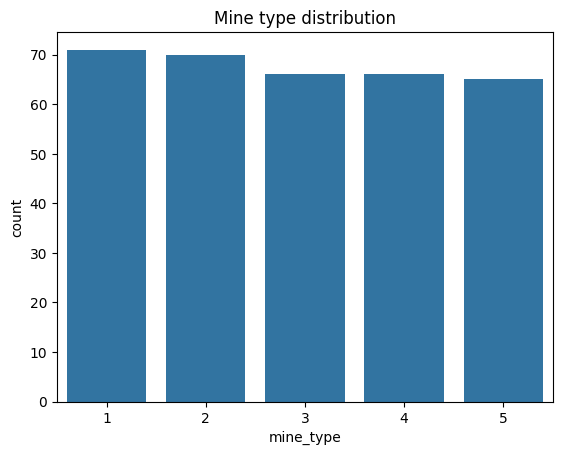

          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000
voltage    196
height      12
soil         6
dtype: int64
voltage    0
height     0
soil       0
dtype: int64
Duplicates: 0


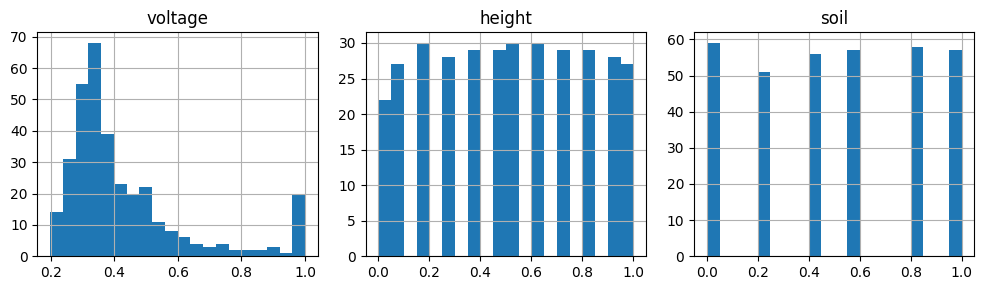

            voltage    height      soil
mine_type                              
1          0.296463  0.495519  0.492958
2          0.721123  0.487013  0.508571
3          0.402408  0.527548  0.496970
4          0.345365  0.506887  0.503030
5          0.379598  0.530070  0.516923


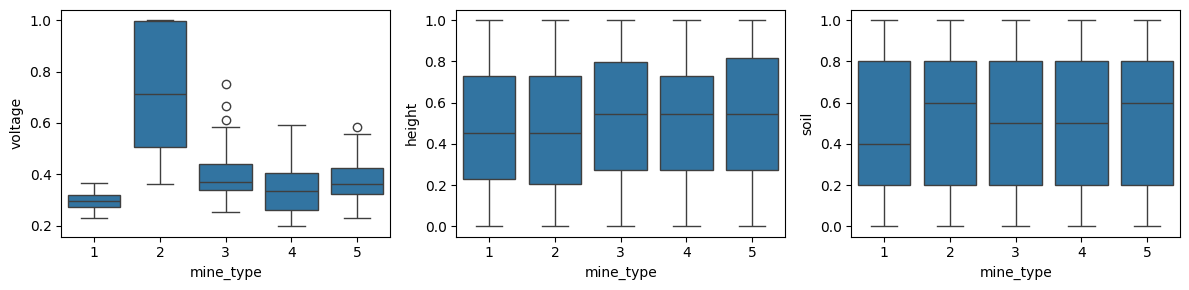

(169, 3) (169, 3)
           train  valid
mine_type              
1             35     36
2             35     35
3             33     33
4             33     33
5             33     32
Best k: 2
Best CV accuracy: 0.4616755793226382


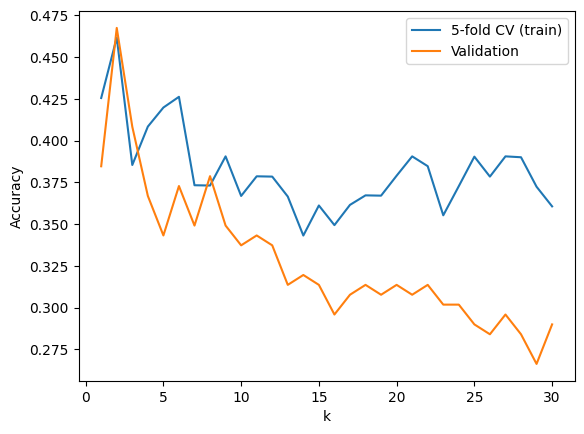

Predicted   1   2   3   4  5
Actual                      
1          27   0   5   2  2
2           0  31   2   1  1
3          10   2  10  10  1
4          15   6   3   9  0
5          15   0  10   5  2
Accuracy: 0.46745562130177515
Actual
1    0.75
2    0.89
3    0.30
4    0.27
5    0.06
dtype: float64


In [14]:
#Q2.1:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

url = "./land_mines.csv"
df = pd.read_csv(url)
#data loading din din din din


target = "mine_type"
features = ["voltage", "height", "soil"]

print(df.shape)
print(df[target].value_counts().sort_index())
print(df[target].value_counts(normalize=True).sort_index())
sns.countplot(x=target, data=df)
plt.title("Mine type distribution")
plt.show()

print(df[features].describe())
print(df[features].nunique())
print(df[features].isna().sum())
print("Duplicates:", df.duplicated().sum())

df[features].hist(bins=20, figsize=(10, 3), layout=(1, 3))
plt.tight_layout()
plt.show()

# feature vs. target
print(df.groupby(target)[features].mean())

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col in zip(axes, features):
    sns.boxplot(x=target, y=col, data=df, ax=ax)
plt.tight_layout()
plt.show()

#target label can be seen as the mine type with it consisting of five categorical classes that are balanced (65-71 rows each, 338 rows total).
#features include voltage (numeric), height (numeric, 12 discrete values), and soil (6 discrete levels). All features are scaled 0-1.
#there are no missing values and no duplicate rows.
#voltage differs the most across classes (type 2 averages about 0.72 vs. 0.30-0.40 for the others), while height and soil barely differ.


#Q2.2


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.50, stratify=eval_y, random_state=65
)
# stratify=eval_y keeps every class in both halves in similar proportions,
# so no class ends up entirely in the training or test data.

# scaler is fit on the training set only, then applied to the validation set, to avoid leakage
eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)

print(eval_X_train_raw.shape, eval_X_valid_raw.shape)
print(pd.DataFrame({
    "train": eval_y_train.value_counts().sort_index(),
    "valid": eval_y_valid.value_counts().sort_index(),
}))


#Q2.3

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

k_values = range(1, 31)
cv_scores = []
valid_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # k selected using cross-validation on the training set
    cv_scores.append(cross_val_score(knn, eval_X_train_scaled, eval_y_train, cv=5).mean())
    # validation accuracy used for comparison
    knn.fit(eval_X_train_scaled, eval_y_train)
    valid_scores.append(knn.score(eval_X_valid_scaled, eval_y_valid))

best_k = k_values[int(np.argmax(cv_scores))]
print("Best k:", best_k)
print("Best CV accuracy:", max(cv_scores))

plt.plot(k_values, cv_scores, label="5-fold CV (train)")
plt.plot(k_values, valid_scores, label="Validation")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#trained kNN classifiers on scaled training data for k = 1 to 30, estimating accuracy with 5-fold cross-validation on solely the training set,
#and chose the k with the highest mean accuracy (k = 2). The validation set stays untouched as a final check.
#small k overfits (k = 1 has perfect training accuracy but poor validation accuracy) while large k underfits, so accuracy peaks at the low end.

#Q2.4

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(eval_X_train_scaled, eval_y_train)
pred = knn.predict(eval_X_valid_scaled)

# confusion table
cm = pd.crosstab(eval_y_valid, pred, rownames=["Actual"], colnames=["Predicted"])
print(cm)

# accuracy
print("Accuracy:", accuracy_score(eval_y_valid, pred))

# accuracy per class
print((pd.Series(cm.values.diagonal(), index=cm.index) / cm.sum(axis=1)).round(2))

#k-NN model showcases 47% accuracy on the test set (79 of 169), above the 20 percent from random guessing.
#type 2 and type 1 boast the best at 89% and 75% respectively, the worst on type 3 and type 4 (about 30% and 27%), near failing at type 5 (6%, mostly predicted as type 1 or 3).
#performance is at its best when voltage separates the class (type 2) and worse when classes overlap on all three features.

#Q2.5 -
#I would advise one to use the model as a screening aid, not as the final word on the type of mine itself. Predictions should be utilized as ways to verify, checks before anything is acted upon.
#Be wary of what is classified as type 1: only about 40% of "type 1" predictions are correct because types 3, 4 and 5 are often mislabeled as type 1, so it is important to take into account the possibilities of overlap.
#"Type 2" predictions are the most reliable (about 89% recall, 79% precision). Types 1, 3, 4 and 5 should be verified with a second check (another sensor or manual inspection) before acting on them.
#A prediction should never be treated as proof that an object is safe, especially since type 5 is only caught about 6% of the time.

The transition to Claude was rather seamless as I was able to derive rationally the content needed to be added to ensure robust representation. A lot of Claude's suggestions tailored around the expansion of my answering of each problem of question 2. A lot of missed prints to further explain my answers was a consistent, recurring theme from Claude's suggestions fixed and altered. Overall just better elaboration of the approaches and corresponding outcomes of my results being executed more explicitly, which I appreciate being clear about that. In terms of mistakes or difficulties presented by Claude or rather executed by outcome from Claude, the same story presented itself as previous ones. Over specifying and making sure information was more robust than maybe what was asked was Claude's technical way of following instruction to the bone. Claude ensuring all components of question 2 was to be finalized is the main reason why I will continue to utilize this AI model for more data analysis executions.
